In [1]:
import pandas as pd
import numpy as np
import itertools
import os
from Generation.Generator import *
df = pd.read_csv(r"tsib\data\episcope\episcope.csv")

In [2]:
df = pd.read_csv(r"tsib\data\episcope\episcope.csv")

In [3]:
episcope_combis(r"tsib\data\episcope\episcope.csv")

[{'Type': 'AB', 'Surrounding': 'Terraced', 'AgeBin': 'DE.02'},
 {'Type': 'AB', 'Surrounding': 'Semi', 'AgeBin': 'DE.03'},
 {'Type': 'AB', 'Surrounding': 'Detached', 'AgeBin': 'DE.04'},
 {'Type': 'AB', 'Surrounding': 'Detached', 'AgeBin': 'DE.05'},
 {'Type': 'AB', 'Surrounding': 'Detached', 'AgeBin': 'DE.06'},
 {'Type': 'MFH', 'Surrounding': 'Detached', 'AgeBin': 'DE.01'},
 {'Type': 'MFH', 'Surrounding': 'Terraced', 'AgeBin': 'DE.02'},
 {'Type': 'MFH', 'Surrounding': 'Detached', 'AgeBin': 'DE.03'},
 {'Type': 'MFH', 'Surrounding': 'Detached', 'AgeBin': 'DE.04'},
 {'Type': 'MFH', 'Surrounding': 'Semi', 'AgeBin': 'DE.05'},
 {'Type': 'MFH', 'Surrounding': 'Detached', 'AgeBin': 'DE.06'},
 {'Type': 'MFH', 'Surrounding': 'Detached', 'AgeBin': 'DE.07'},
 {'Type': 'MFH', 'Surrounding': 'Detached', 'AgeBin': 'DE.08'},
 {'Type': 'MFH', 'Surrounding': 'Semi', 'AgeBin': 'DE.09'},
 {'Type': 'MFH', 'Surrounding': 'Detached', 'AgeBin': 'DE.10'},
 {'Type': 'MFH', 'Surrounding': 'Detached', 'AgeBin': 'DE

In [5]:
#building type
#n apartments
#occ
# flat area



# Manifest Generator

In [8]:
year_types = ["average", "hot", "cold"]
futures = [False, True]
weather_combis = [(f, y) for f in futures for y in year_types]

In [14]:
weather_combis

[(False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold')]

In [17]:
rng = np.random.default_rng(42)

In [19]:
rng.choice(np.arange(1,16),size=(100%15),replace=False)

array([ 2,  6,  1,  8,  4,  5, 13, 15,  3, 10])

In [21]:
np.tile(np.arange(1,16),6)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  1,  2,
        3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  1,  2,  3,  4,
        5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  1,  2,  3,  4,  5,  6,
        7,  8,  9, 10, 11, 12, 13, 14, 15,  1,  2,  3,  4,  5,  6,  7,  8,
        9, 10, 11, 12, 13, 14, 15,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       11, 12, 13, 14, 15])

In [9]:
[weather_combis[i % len(weather_combis)] for i in range(90)]

[(False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold'),
 (False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold'),
 (False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold'),
 (False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold'),
 (False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold'),
 (False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold'),
 (False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold'),
 (False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold'),
 (False, 'average'),
 (False, 'hot'),
 (False, 'cold'),
 (True, 'average'),
 (True, 'hot'),
 (True, 'cold'),
 (False, 'average')

In [ ]:
weather_scenario = [weather_scenario[i] for i in rng.permutation(n_scenarios)]

In [16]:
100 % 15

10

In [22]:
def manifest(scenario_reps,seed_reps,episcope_path , building_types= ["SFH", "MFH", "TH", "AB"],seed=42, out_path="manifest.parquet", overwrite=False):
    building_combis = episcope_combis(episcope_path, building_types=building_types)
    year_types = ["average", "hot", "cold"]
    futures = [False, True]
    weather_combis = [(f, y) for f in futures for y in year_types]
    rng = np.random.default_rng(seed)
    rows = []
    building_id = 0

    def building_type_reps(building_type):
        return scenario_reps[building_type] if isinstance(scenario_reps, dict) else scenario_reps

    for x in building_combis:
        building_type = x["Type"]
        surrounding = x["Surrounding"]
        buildingAgeBin = x["AgeBin"]

        n_scenarios = building_type_reps(building_type)

        weather_scenario =[weather_combis[i % len(weather_combis)] for i in range(n_scenarios)]
        rng.shuffle(weather_scenario)

        climate_regions = np.arange(1, 16)
        base = np.tile(climate_regions,n_scenarios // len(climate_regions))
        remainder = n_scenarios % len(climate_regions)
        extra = rng.choice(climate_regions,size=remainder,replace=False)
        region_scenario = np.concatenate([base, extra])
        rng.shuffle(region_scenario)


        for i in range(n_scenarios):
            n_flats = gen_flat_count(buildingtype=building_type, rng=rng)
            occs = gen_occs(buildingtype=building_type, apartment_count=n_flats, rng=rng)
            flat_areas = gen_flat_area(occs=occs,rng=rng)
            total_area = sum(flat_areas)
            clima_region = region_scenario[i]
            future, year_type = weather_scenario[i]
            for _ in range(seed_reps):
                rows.append(dict(
                    country = "DE",
                    buildingType = building_type,
                    surrounding = surrounding,
                    buildingAgeBin = buildingAgeBin,
                    a_ref = round(total_area,1),
                    n_apartments = n_flats,
                    year_type = year_type,
                    future = future,
                    climateRegion = clima_region,
                    n_persons = occs,
                    freq = "1min",
                    hasFirePlace = False,
                    cores = 1,
                    useCache=False,
                    building_id = building_id,

                )
                 )
            building_id += 1

    manifest = pd.DataFrame(rows)
    manifest["run_id"] = manifest.index.map(lambda i: f"run_{i:06d}")
    manifest["seed"]= 1000000 + manifest.index
    if os.path.exists(out_path) and not overwrite:
        raise FileExistsError()
    manifest.to_parquet(out_path)
    return manifest


In [29]:
manifest2 = manifest(scenario_reps=1,
                    seed_reps=1,
                    episcope_path=r"tsib\data\episcope\episcope.csv",
                    building_types= ["SFH", "MFH", "TH", "AB"],
                    seed=42, overwrite=True)


In [30]:
manifest2

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,freq,hasFirePlace,cores,useCache,building_id,run_id,seed
0,DE,AB,Terraced,DE.02,1865.2,19,average,False,2,"[1, 3, 2, 1, 5, 2, 2, 1, 1, 1, 4, 2, 3, 1, 1, ...",1min,False,1,False,0,run_000000,1000000
1,DE,AB,Semi,DE.03,1083.3,14,average,False,1,"[1, 2, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 3]",1min,False,1,False,1,run_000001,1000001
2,DE,AB,Detached,DE.04,1614.7,18,average,False,8,"[1, 4, 2, 2, 1, 1, 1, 4, 1, 1, 1, 2, 1, 3, 2, ...",1min,False,1,False,2,run_000002,1000002
3,DE,AB,Detached,DE.05,1485.3,15,average,False,2,"[2, 2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]",1min,False,1,False,3,run_000003,1000003
4,DE,AB,Detached,DE.06,1593.6,17,average,False,8,"[1, 1, 1, 1, 2, 1, 2, 2, 2, 1, 3, 2, 2, 1, 1, ...",1min,False,1,False,4,run_000004,1000004
5,DE,MFH,Detached,DE.01,384.9,5,average,False,5,"[2, 3, 1, 1, 2]",1min,False,1,False,5,run_000005,1000005
6,DE,MFH,Terraced,DE.02,328.1,3,average,False,11,"[1, 1, 2]",1min,False,1,False,6,run_000006,1000006
7,DE,MFH,Detached,DE.03,156.9,3,average,False,9,"[1, 1, 1]",1min,False,1,False,7,run_000007,1000007
8,DE,MFH,Detached,DE.04,1063.6,11,average,False,2,"[1, 4, 1, 3, 4, 5, 3, 2, 2, 2, 1]",1min,False,1,False,8,run_000008,1000008
9,DE,MFH,Semi,DE.05,1092.4,11,average,False,15,"[2, 3, 2, 2, 1, 2, 1, 2, 3, 1, 2]",1min,False,1,False,9,run_000009,1000009


In [ ]:
import numpy as np

manifest = pd.read_parquet("manifest.parquet")  # your real manifest
seen = {}
collisions = 0
for _, row in manifest.iterrows():
    draw = np.random.RandomState(row["seed"]).choice(5_000_000, size=row["n_apartments"], replace=False)
    for idx in draw:
        key = (row["n_persons"], idx)  # cache key also includes n_persons/freq
        if key in seen:
            collisions += 1
        seen[key] = True

print(f"{collisions} collisions out of {sum(manifest['n_apartments'])} total draws")

In [7]:
assert (manifest2["n_persons"].apply(len) == manifest2["n_apartments"]).all(), "n_persons/n_apartments mismatch"
print(len(manifest2), "total rows")
print(manifest2.groupby("buildingType")["n_apartments"].describe())

240 total rows
              count       mean       std   min    25%   50%    75%   max
buildingType                                                            
AB             30.0  16.066667  2.333169  13.0  14.25  15.5  17.75  20.0
MFH            72.0   7.805556  2.938999   3.0   5.00   8.0  10.00  12.0
SFH            72.0   1.000000  0.000000   1.0   1.00   1.0   1.00   1.0
TH             66.0   1.469697  0.502905   1.0   1.00   1.0   2.00   2.0


In [8]:
manifest2

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,freq,hasFirePlace,cores,useCache,scenario_id,run_id,seed
0,DE,AB,Terraced,DE.02,1292.0,13,average,False,12,"[1, 3, 2, 1, 5, 2, 2, 1, 1, 1, 4, 2, 3]",1min,False,1,False,0,run_000000,1000000
1,DE,AB,Terraced,DE.02,1657.6,20,average,True,7,"[3, 2, 1, 3, 3, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, ...",1min,False,1,False,1,run_000001,1000001
2,DE,AB,Terraced,DE.02,1386.1,16,hot,False,11,"[1, 4, 2, 2, 1, 1, 1, 4, 1, 1, 1, 2, 1, 3, 2, 2]",1min,False,1,False,2,run_000002,1000002
3,DE,AB,Terraced,DE.02,1501.5,15,hot,True,13,"[3, 1, 2, 1, 2, 1, 2, 2, 2, 1, 4, 1, 1, 2, 1]",1min,False,1,False,3,run_000003,1000003
4,DE,AB,Terraced,DE.02,1416.9,15,cold,False,9,"[3, 1, 1, 2, 4, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2]",1min,False,1,False,4,run_000004,1000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,DE,TH,Semi,DE.12,186.1,1,average,True,5,[3],1min,False,1,False,235,run_000235,1000235
236,DE,TH,Semi,DE.12,53.7,1,hot,False,10,[2],1min,False,1,False,236,run_000236,1000236
237,DE,TH,Semi,DE.12,77.8,1,hot,True,9,[2],1min,False,1,False,237,run_000237,1000237
238,DE,TH,Semi,DE.12,157.3,2,cold,False,10,"[2, 2]",1min,False,1,False,238,run_000238,1000238


In [9]:
pd.read_parquet(r"Generation\manifest.parquet")

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,freq,hasFirePlace,cores,useCache,scenario_id,run_id,seed
0,DE,AB,Terraced,DE.02,1292.0,13,average,False,12,"[1, 3, 2, 1, 5, 2, 2, 1, 1, 1, 4, 2, 3]",1min,False,1,False,0,run_000000,1000000
1,DE,AB,Terraced,DE.02,1657.6,20,average,True,7,"[3, 2, 1, 3, 3, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, ...",1min,False,1,False,1,run_000001,1000001
2,DE,AB,Terraced,DE.02,1386.1,16,hot,False,11,"[1, 4, 2, 2, 1, 1, 1, 4, 1, 1, 1, 2, 1, 3, 2, 2]",1min,False,1,False,2,run_000002,1000002
3,DE,AB,Terraced,DE.02,1501.5,15,hot,True,13,"[3, 1, 2, 1, 2, 1, 2, 2, 2, 1, 4, 1, 1, 2, 1]",1min,False,1,False,3,run_000003,1000003
4,DE,AB,Terraced,DE.02,1416.9,15,cold,False,9,"[3, 1, 1, 2, 4, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2]",1min,False,1,False,4,run_000004,1000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,DE,TH,Semi,DE.12,186.1,1,average,True,5,[3],1min,False,1,False,235,run_000235,1000235
236,DE,TH,Semi,DE.12,53.7,1,hot,False,10,[2],1min,False,1,False,236,run_000236,1000236
237,DE,TH,Semi,DE.12,77.8,1,hot,True,9,[2],1min,False,1,False,237,run_000237,1000237
238,DE,TH,Semi,DE.12,157.3,2,cold,False,10,"[2, 2]",1min,False,1,False,238,run_000238,1000238


In [16]:
manifest2.loc[[101,102]]

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,freq,hasFirePlace,cores,useCache,scenario_id,run_id,seed
101,DE,MFH,Detached,DE.12,721.6,10,cold,True,10,"[4, 1, 1, 1, 1, 1, 1, 2, 2, 2]",1min,False,1,False,101,run_000101,1000101
102,DE,SFH,Detached,DE.01,58.1,1,average,False,4,[1],1min,False,1,False,102,run_000102,1000102


# Generator

In [ ]:
manifest_run("Generation/manifest.parquet",res_dir="Generation/results", fail_log="failures.log", max_cores=19)

Total:240, Remain: 111, Done: 129


Running Simulations:  23%|██▎       | 26/111 [04:32<07:39,  5.41s/runs, done=26, failed=0] 

In [14]:
import pandas as pd

path = r"C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\Generation\results\run_000047.h5"

# see what's actually stored inside, in case you forget the exact keys
with pd.HDFStore(path, mode="r") as store:
    print(store.keys())   # -> ['/timeseries', '/params']

timeseries = pd.read_hdf(path, key="timeseries")
params = pd.read_hdf(path, key="params")

print(params.T)          # transpose — easier to read a one-row table this way
print(timeseries.head())
print(timeseries.dtypes)

['/params', '/timeseries']
                                                                        0
country                                                                DE
buildingType                                                          SFH
surrounding                                                      Detached
buildingAgeBin                                                      DE.12
a_ref                                                               115.8
n_apartments                                                            1
year_type                                                         average
future                                                              False
climateRegion                                                           4
n_persons                                                             [3]
freq                                                                 1min
hasFirePlace                                                        False
cores      

In [32]:
store = pd.HDFStore(r"C:\Users\Samuel\Downloads\Ziel\test.h5", mode="w")

In [ ]:
os.replace()

In [38]:
store.put("manifest", df, format="table")

In [39]:
store.close()

In [41]:
store.open()

In [42]:
store.select("manifest")

,Unnamed: 0,Code_BuildingVariant,Date_Entry,Code_StatusDataset,Code_Country,Code_Building,Description_BuildingVariant,Description_BuildingVariant_National,Code_BuildingType,Code_DataType_Building,...,Q_Sol_South,Q_Sol_West,Q_Sol_North,q_sol,q_int,tau,a_H,gamma_h_gn,eta_h_gn,q_h_nd
0,11,AT.N.AB.01.Gen.ReEx.001.001,2015-09-04 00:00:00,Typology,AT,AT.N.AB.01.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.01.Gen,ReEx,...,0.000000,6113.728530,0.000000,8.975227,15.264,16.882835,1.362761,0.121795,0.949819,175.994029
1,14,AT.N.AB.02.Gen.ReEx.001.001,2010-09-07 00:00:00,Typology,AT,AT.N.AB.02.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.02.Gen,ReEx,...,111.334041,4263.592788,41.090868,8.083775,15.264,13.099762,1.236659,0.093664,0.951285,227.060285
2,17,AT.N.AB.03.Gen.ReEx.001.001,2010-09-07 00:00:00,Typology,AT,AT.N.AB.03.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.03.Gen,ReEx,...,5296.741632,355.400136,2335.270392,9.980548,15.264,15.986860,1.332895,0.120774,0.947081,185.113920
3,20,AT.N.AB.04.Gen.ReEx.001.001,2010-09-07 00:00:00,Typology,AT,AT.N.AB.04.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.04.Gen,ReEx,...,11725.543557,265.341258,2134.543320,15.381327,15.264,15.670092,1.322336,0.144009,0.933254,184.201843
4,23,AT.N.AB.05.Gen.ReEx.001.001,2010-09-07 00:00:00,Typology,AT,AT.N.AB.05.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.05.Gen,ReEx,...,5842.574010,469.031472,3886.177932,7.645423,15.264,45.440649,2.314688,0.281850,0.961117,59.263580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,2979,SI.N.MFH-AB.03-04.Gen.SyAv.001.001,2015-07-03 00:00:00,Analysis,SI,SI.N.MFH-AB.03-04.Gen.SyAv.001,0,0,SI.N.MFH-AB.03-04.Gen,SyAv,...,9069.457950,6771.033675,3043.859175,8.547734,14.832,23.406668,1.580222,0.167339,0.950122,117.501205
832,2980,SI.N.MFH-AB.05-06.Gen.SyAv.001.001,2015-07-03 00:00:00,Analysis,SI,SI.N.MFH-AB.05-06.Gen.SyAv.001,0,0,SI.N.MFH-AB.05-06.Gen,SyAv,...,14004.334417,10455.290764,4700.084839,6.697053,14.832,52.073181,2.535773,0.320371,0.961403,46.502309
833,2981,SI.N.SFH-TH.01-02.Gen.SyAv.001.001,2015-07-03 00:00:00,Analysis,SI,SI.N.SFH-TH.01-02.Gen.SyAv.001,0,0,SI.N.SFH-TH.01-02.Gen,SyAv,...,649.838700,485.153550,218.096550,12.847136,14.832,12.861238,1.228708,0.122245,0.933030,200.597076
834,2982,SI.N.SFH-TH.03-04.Gen.SyAv.001.001,2015-07-03 00:00:00,Analysis,SI,SI.N.SFH-TH.03-04.Gen.SyAv.001,0,0,SI.N.SFH-TH.03-04.Gen,SyAv,...,411.943927,307.547179,138.255154,7.930485,14.832,22.540807,1.551360,0.166208,0.947942,115.374672


Rows: 14,400
Unique buildings: 3,600
Unique runs: 14,400

DATA TYPES
country            object
buildingType       object
surrounding        object
buildingAgeBin     object
a_ref             float64
n_apartments        int64
year_type          object
future               bool
climateRegion       int64
n_persons          object
freq               object
hasFirePlace         bool
cores               int64
useCache             bool
building_id         int64
run_id             object
seed                int64
dtype: object

MISSING VALUES
country           0
buildingType      0
surrounding       0
buildingAgeBin    0
a_ref             0
n_apartments      0
year_type         0
future            0
climateRegion     0
n_persons         0
freq              0
hasFirePlace      0
cores             0
useCache          0
building_id       0
run_id            0
seed              0
dtype: int64

NUMERIC PARAMETER SUMMARY
                 count        mean         std   min      25%     50%     75%  

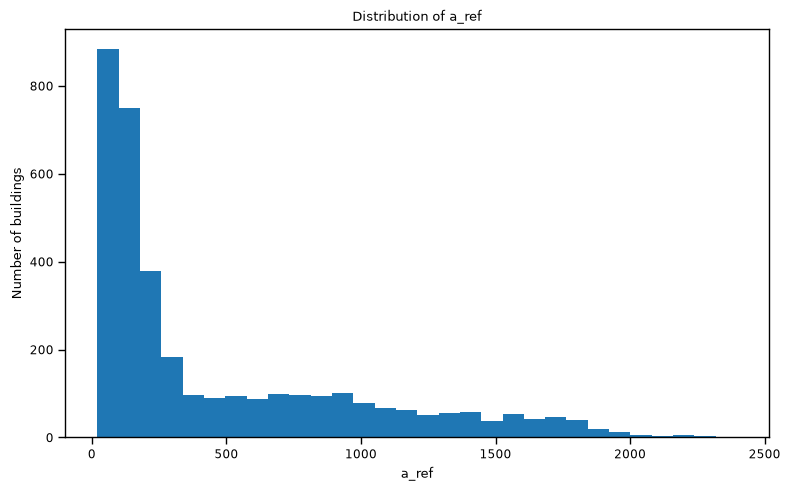

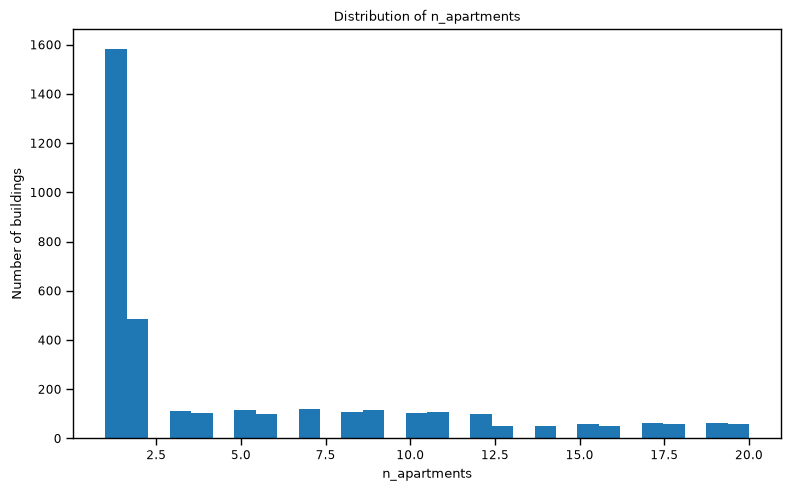

REFERENCE AREA BY BUILDING TYPE
               count         mean         std    min       25%      50%  \
buildingType                                                              
AB             450.0  1535.392889  268.368715  905.3  1339.725  1540.45   
MFH           1080.0   693.543704  286.675660  121.5   463.700   687.25   
SFH           1080.0   101.455463   43.035787   20.3    68.150    92.90   
TH             990.0   155.775556   76.374492   20.1    92.100   140.50   

                   75%     max  
buildingType                    
AB            1718.225  2397.6  
MFH            915.625  1487.3  
SFH            130.325   200.0  
TH             205.450   382.2  



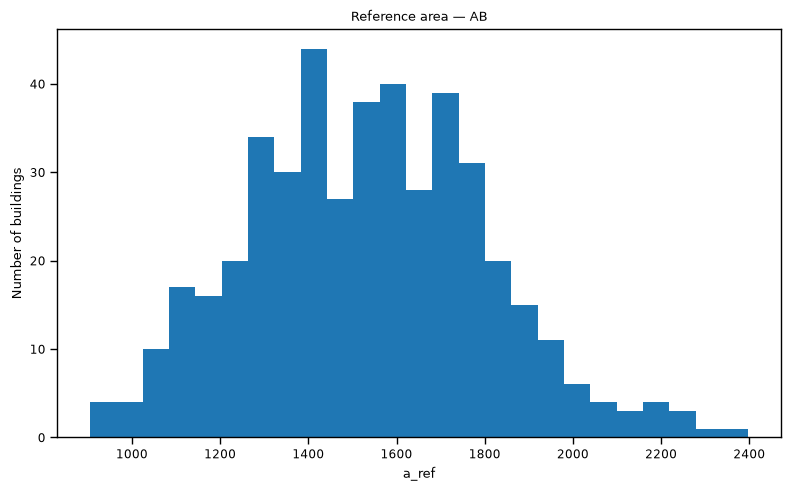

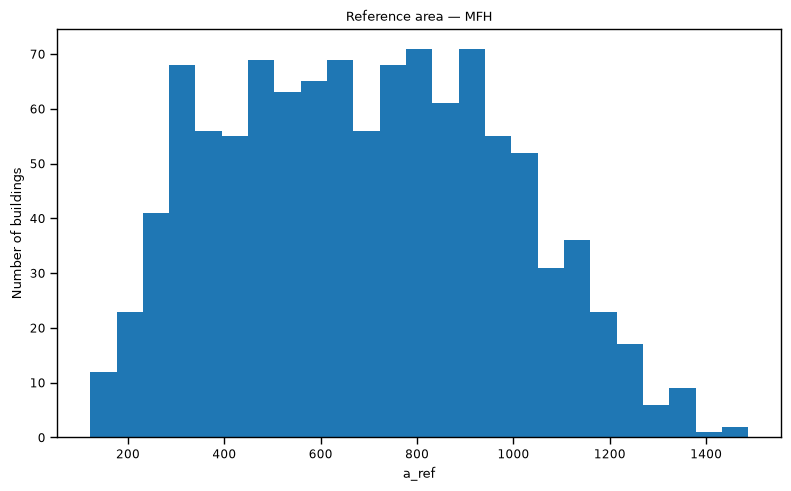

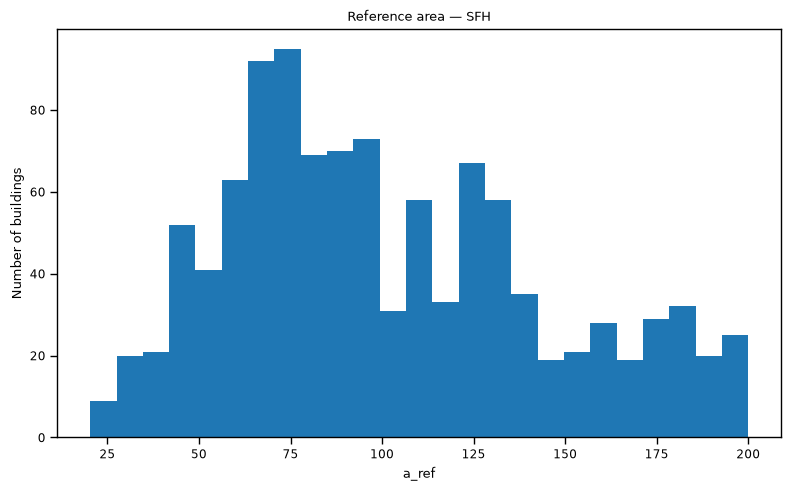

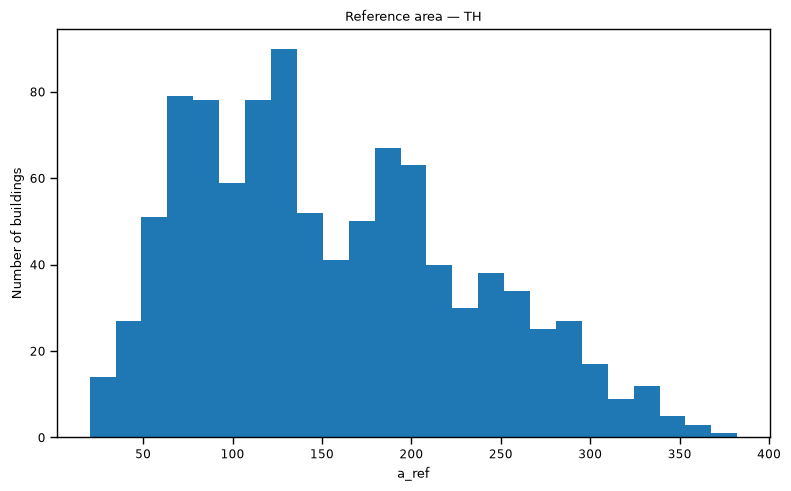

APARTMENT COUNT BY BUILDING TYPE
               count       mean       std   min   25%   50%   75%   max
buildingType                                                           
AB             450.0  16.624444  2.272882  13.0  15.0  17.0  19.0  20.0
MFH           1080.0   7.441667  2.843187   3.0   5.0   7.0  10.0  12.0
SFH           1080.0   1.000000  0.000000   1.0   1.0   1.0   1.0   1.0
TH             990.0   1.490909  0.500170   1.0   1.0   1.0   2.0   2.0

CLIMATE REGION × BUILDING TYPE
climateRegion  1   2   3   4   5   6   7   8   9   10  11  12  13  14  15
buildingType                                                             
AB             30  30  30  30  30  30  30  30  30  30  30  30  30  30  30
MFH            72  72  72  72  72  72  72  72  72  72  72  72  72  72  72
SFH            72  72  72  72  72  72  72  72  72  72  72  72  72  72  72
TH             66  66  66  66  66  66  66  66  66  66  66  66  66  66  66

WEATHER SCENARIO × BUILDING TYPE
future         False     

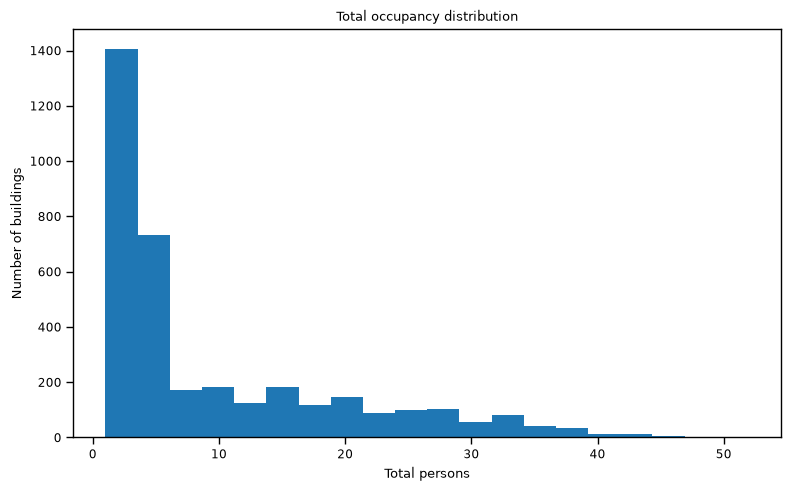


AREA PER PERSON
count    3600.000000
mean       50.869722
std        20.351617
min        11.075000
25%        38.638816
50%        48.591503
75%        59.205172
max       193.700000
Name: area_per_person, dtype: float64


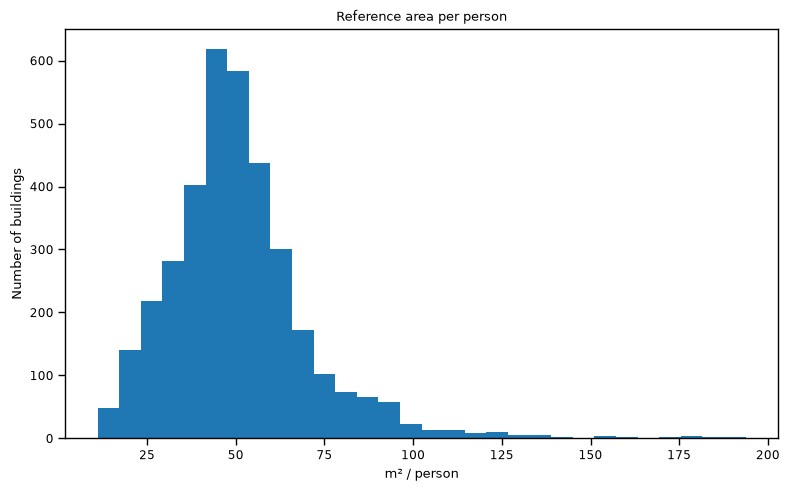

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

MANIFEST_PATH = "manifest.parquet"

# --------------------------------------------------
# Load manifest
# --------------------------------------------------
df = pd.read_parquet(MANIFEST_PATH)

print(f"Rows: {len(df):,}")
print(f"Unique buildings: {df['building_id'].nunique():,}")
print(f"Unique runs: {df['run_id'].nunique():,}")
print()


# --------------------------------------------------
# 1. Basic overview
# --------------------------------------------------
print("=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)
print()


print("=" * 80)
print("MISSING VALUES")
print("=" * 80)
print(df.isna().sum().sort_values(ascending=False))
print()


# --------------------------------------------------
# 2. Numeric parameter statistics
# --------------------------------------------------
numeric_cols = [
    "a_ref",
    "n_apartments",
    "climateRegion",
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

print("=" * 80)
print("NUMERIC PARAMETER SUMMARY")
print("=" * 80)
print(df[numeric_cols].describe().T)
print()


# --------------------------------------------------
# 3. Categorical distributions
# --------------------------------------------------
categorical_cols = [
    "buildingType",
    "surrounding",
    "buildingAgeBin",
    "year_type",
    "future",
    "climateRegion",
]

for col in categorical_cols:
    if col not in df.columns:
        continue

    print("=" * 80)
    print(f"DISTRIBUTION: {col}")
    print("=" * 80)

    counts = df[col].value_counts(dropna=False).sort_index()
    percentages = df[col].value_counts(
        normalize=True,
        dropna=False
    ).sort_index() * 100

    distribution = pd.DataFrame({
        "count": counts,
        "percent": percentages
    })

    print(distribution)
    print()


# --------------------------------------------------
# 4. IMPORTANT:
# Avoid counting seed repetitions as distinct buildings
# --------------------------------------------------
building_df = (
    df
    .drop_duplicates("building_id")
    .copy()
)

print("=" * 80)
print("BUILDING-LEVEL DATA")
print("=" * 80)
print(f"Simulation rows: {len(df):,}")
print(f"Distinct building scenarios: {len(building_df):,}")
print()


# --------------------------------------------------
# 5. Building-level distributions
# --------------------------------------------------
for col in categorical_cols:
    if col not in building_df.columns:
        continue

    print("=" * 80)
    print(f"BUILDING-LEVEL DISTRIBUTION: {col}")
    print("=" * 80)

    counts = building_df[col].value_counts(dropna=False).sort_index()
    percentages = building_df[col].value_counts(
        normalize=True,
        dropna=False
    ).sort_index() * 100

    print(pd.DataFrame({
        "count": counts,
        "percent": percentages
    }))
    print()


# --------------------------------------------------
# 6. Histograms of important numeric building params
# --------------------------------------------------
hist_cols = [
    "a_ref",
    "n_apartments",
]

for col in hist_cols:
    if col not in building_df.columns:
        continue

    plt.figure(figsize=(8, 5))
    plt.hist(building_df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Number of buildings")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 7. Reference area by building type
# --------------------------------------------------
if {"buildingType", "a_ref"}.issubset(building_df.columns):

    print("=" * 80)
    print("REFERENCE AREA BY BUILDING TYPE")
    print("=" * 80)

    print(
        building_df
        .groupby("buildingType")["a_ref"]
        .describe()
    )
    print()

    building_types = building_df["buildingType"].dropna().unique()

    for building_type in sorted(building_types):
        subset = building_df.loc[
            building_df["buildingType"] == building_type,
            "a_ref"
        ]

        plt.figure(figsize=(8, 5))
        plt.hist(subset.dropna(), bins=25)
        plt.xlabel("a_ref")
        plt.ylabel("Number of buildings")
        plt.title(f"Reference area — {building_type}")
        plt.tight_layout()
        plt.show()


# --------------------------------------------------
# 8. Apartment count by building type
# --------------------------------------------------
if {"buildingType", "n_apartments"}.issubset(building_df.columns):

    print("=" * 80)
    print("APARTMENT COUNT BY BUILDING TYPE")
    print("=" * 80)

    print(
        building_df
        .groupby("buildingType")["n_apartments"]
        .describe()
    )
    print()


# --------------------------------------------------
# 9. Climate region coverage by building type
# --------------------------------------------------
if {"buildingType", "climateRegion"}.issubset(building_df.columns):

    climate_table = pd.crosstab(
        building_df["buildingType"],
        building_df["climateRegion"]
    )

    print("=" * 80)
    print("CLIMATE REGION × BUILDING TYPE")
    print("=" * 80)
    print(climate_table)
    print()


# --------------------------------------------------
# 10. Weather coverage by building type
# --------------------------------------------------
if {
    "buildingType",
    "future",
    "year_type"
}.issubset(building_df.columns):

    weather_table = pd.crosstab(
        building_df["buildingType"],
        [
            building_df["future"],
            building_df["year_type"]
        ]
    )

    print("=" * 80)
    print("WEATHER SCENARIO × BUILDING TYPE")
    print("=" * 80)
    print(weather_table)
    print()


# --------------------------------------------------
# 11. Check seed repetitions per building
# --------------------------------------------------
reps = df.groupby("building_id").size()

print("=" * 80)
print("SEED REPETITIONS PER BUILDING")
print("=" * 80)
print(reps.value_counts().sort_index())
print()

if reps.nunique() == 1:
    print(f"All buildings have exactly {reps.iloc[0]} seed repetitions.")
else:
    print("WARNING: Buildings do not all have the same number of seed repetitions.")


# --------------------------------------------------
# 12. Optional occupancy analysis
# n_persons may contain lists
# --------------------------------------------------
if "n_persons" in building_df.columns:

    def total_people(x):
        if isinstance(x, (list, tuple)):
            return sum(x)
        return x

    building_df["total_persons"] = building_df["n_persons"].apply(total_people)

    print()
    print("=" * 80)
    print("TOTAL OCCUPANCY")
    print("=" * 80)
    print(building_df["total_persons"].describe())

    plt.figure(figsize=(8, 5))
    plt.hist(building_df["total_persons"].dropna(), bins=20)
    plt.xlabel("Total persons")
    plt.ylabel("Number of buildings")
    plt.title("Total occupancy distribution")
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 13. Area per person
# --------------------------------------------------
if {"a_ref", "total_persons"}.issubset(building_df.columns):

    building_df["area_per_person"] = (
        building_df["a_ref"] / building_df["total_persons"]
    )

    print()
    print("=" * 80)
    print("AREA PER PERSON")
    print("=" * 80)
    print(building_df["area_per_person"].describe())

    plt.figure(figsize=(8, 5))
    plt.hist(
        building_df["area_per_person"].dropna(),
        bins=30
    )
    plt.xlabel("m² / person")
    plt.ylabel("Number of buildings")
    plt.title("Reference area per person")
    plt.tight_layout()
    plt.show()

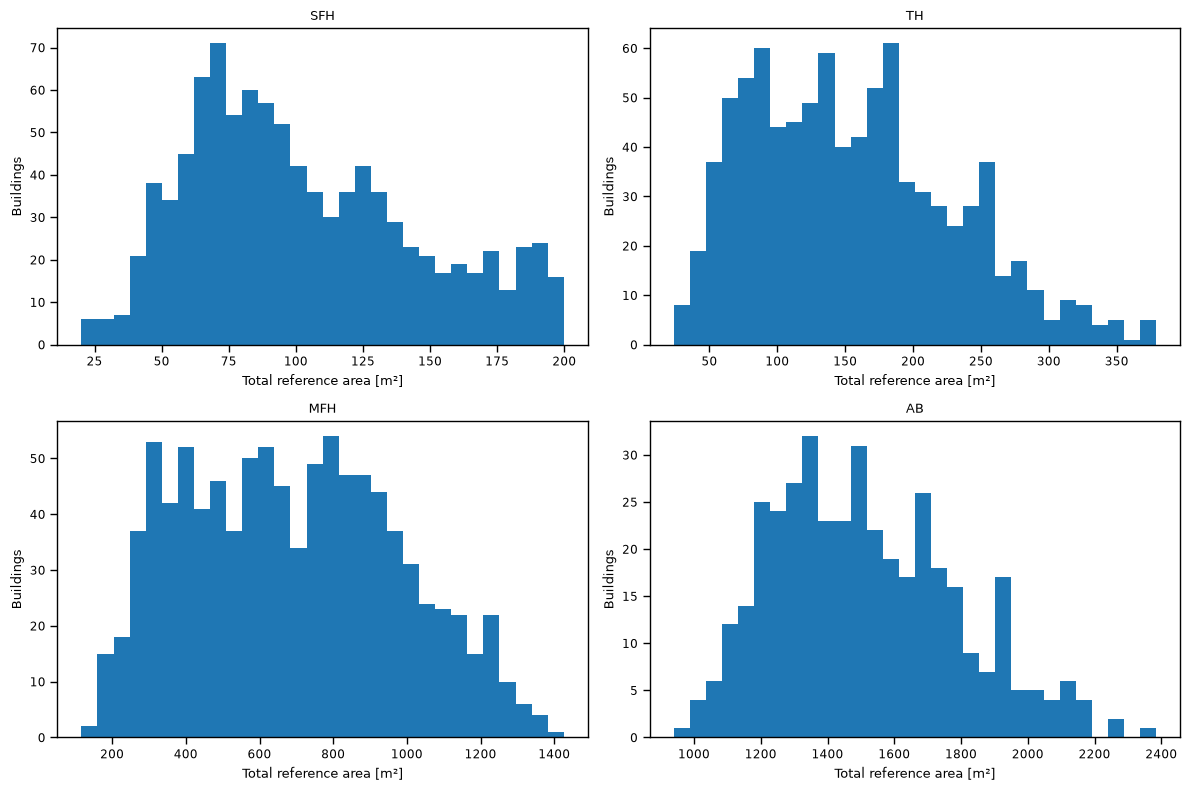

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("manifest.parquet")
b = df.drop_duplicates("building_id").copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, bt in zip(axes.flat, ["SFH", "TH", "MFH", "AB"]):
    x = b.loc[b["buildingType"] == bt, "a_ref"]

    ax.hist(x, bins=30)
    ax.set_title(bt)
    ax.set_xlabel("Total reference area [m²]")
    ax.set_ylabel("Buildings")

plt.tight_layout()
plt.show()

In [25]:
summary = (
    b.groupby("buildingType")
    .agg(
        n=("building_id", "size"),

        area_min=("a_ref", "min"),
        area_q05=("a_ref", lambda x: x.quantile(.05)),
        area_q25=("a_ref", lambda x: x.quantile(.25)),
        area_median=("a_ref", "median"),
        area_q75=("a_ref", lambda x: x.quantile(.75)),
        area_q95=("a_ref", lambda x: x.quantile(.95)),
        area_max=("a_ref", "max"),

        flats_min=("n_apartments", "min"),
        flats_mean=("n_apartments", "mean"),
        flats_max=("n_apartments", "max"),
    )
)

print(summary.round(1))

                n  area_min  area_q05  area_q25  area_median  area_q75  \
buildingType                                                             
AB            400     939.2    1117.4    1301.7       1480.8    1696.2   
MFH           960     116.6     263.4     444.0        673.8     899.8   
SFH           960      20.1      45.1      70.3         93.6     131.0   
TH            880      23.7      53.1      92.8        145.9     203.6   

              area_q95  area_max  flats_min  flats_mean  flats_max  
buildingType                                                        
AB              2014.0    2384.3         13        16.3         20  
MFH             1199.5    1425.8          3         7.4         12  
SFH              185.5     199.8          1         1.0          1  
TH               287.9     379.0          1         1.5          2  


In [26]:
b["area_per_apartment"] = (
    b["a_ref"] / b["n_apartments"]
)

print(
    b.groupby("buildingType")["area_per_apartment"]
    .describe(percentiles=[.05, .25, .5, .75, .95])
    .round(1)
)

              count   mean   std   min    5%   25%   50%    75%    95%    max
buildingType                                                                 
AB            400.0   92.8  10.1  72.2  77.5  85.2  92.5   99.2  110.3  126.3
MFH           960.0   93.2  16.9  38.9  65.6  81.6  92.9  104.1  120.4  161.6
SFH           960.0  102.8  42.5  20.1  45.1  70.3  93.6  131.0  185.5  199.8
TH            880.0  103.2  36.9  23.7  50.3  74.8  98.0  127.2  175.0  198.2
